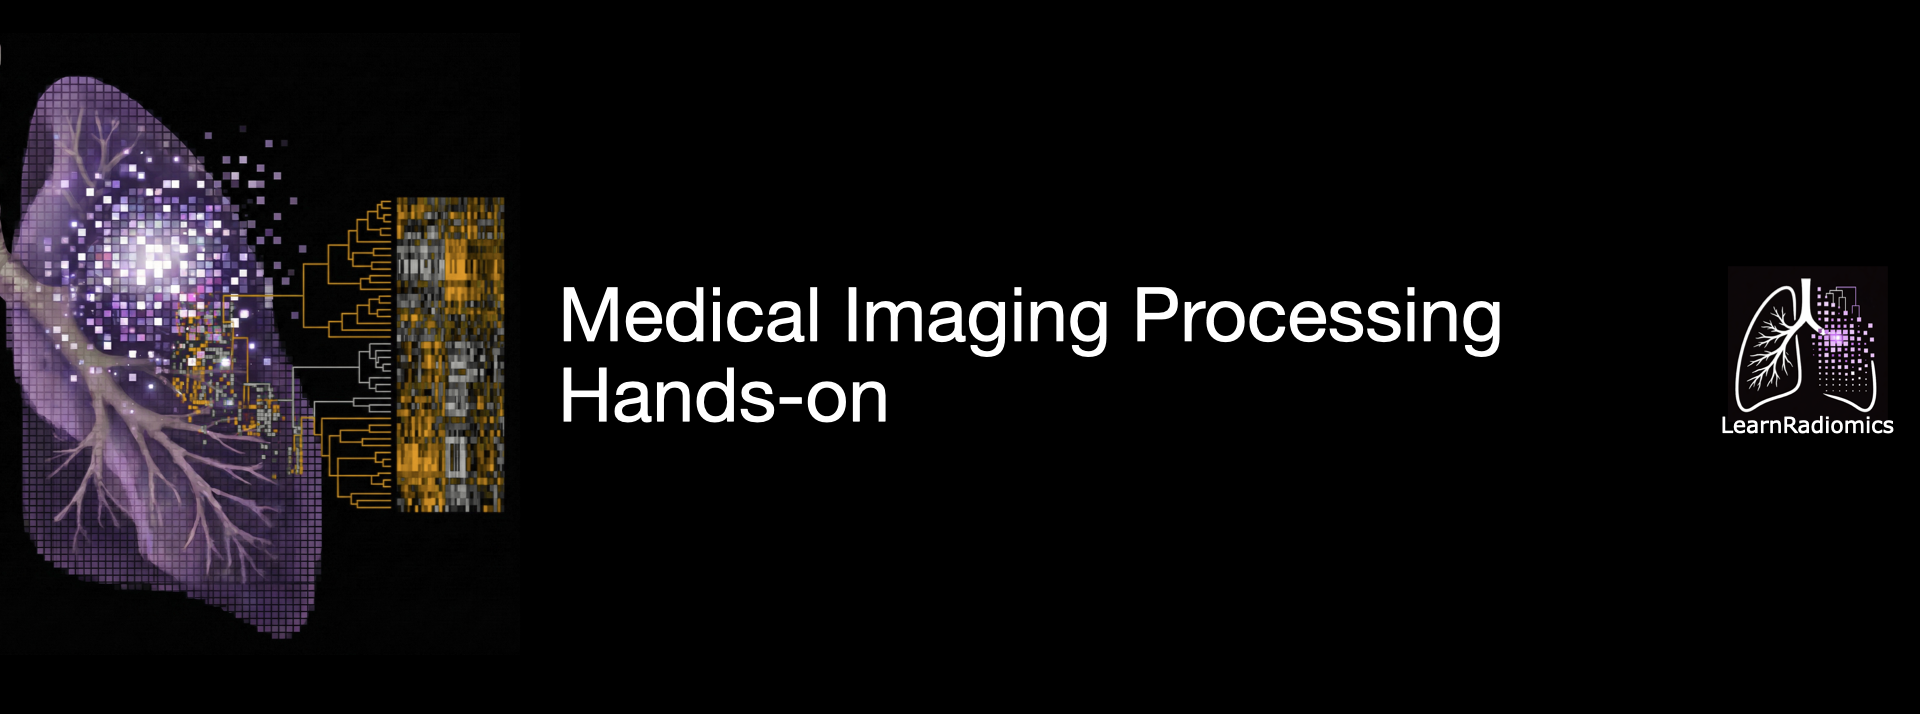

In [ ]:
### We install two specialized medical imaging libraries

! pip install SimpleITK
! pip install pydicom

In [ ]:
import numpy as np
import SimpleITK as sitk
import pydicom
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import cv2
import os
import glob
import requests
import json

## Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Download the Kaggle token that allows access to the dataset
json_response = requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")

token = json.loads(json_response.text)
with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load data from Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/medical-imaging-processing
!unzip /content/medical-imaging-processing

In [ ]:
## We create a visualization function to adjust the histogram

def show_slice_window(slice_array, level, window):
    """
    input: 2D image array,
    allows window and level adjustment to improve image contrast.
    output: windowed 2D image array.
   """
    max_value = level + window / 2
    min_value = level - window / 2
    slice_array = slice_array.clip(min_value, max_value)
    return slice_array

### Directory configuration:
> #### Directory structure:

* /content
* >> /dataset
* >>>/abdominal_ct
* >>>>>/abdominal_ct/image.nii.gz
* >>>>>/abdominal_ct/mask.nii.gz
* >>>/chest_ct
* >>>>>/chest_ct/file1.dcm
* >>>>>/chest_ct/file2.dcm
* >>>>>/chest_ct/....dcm
* >>>/chest_xr
* >>>>>/chest_xr/Rx.dcm



### Read DICOM file

## Load: radiograph


In [ ]:
print(os.getcwd())

In [ ]:
path_radiograph = '/content/dataset/chest_xr/IM-0001-0001.dcm'

In [ ]:
### pyDicom library

# Load the DICOM file: create a DICOM object
ds = pydicom.dcmread(path_radiograph)
print(ds)

In [ ]:
### Access specific fields:
print("Name:", ds.PatientName)
print("KVP:", ds.KVP)
print("Exposure Time:", ds.ExposureTime)
print("Tube Current:", ds.XRayTubeCurrent)
print("Scanner manufacturer:", ds.Manufacturer)

In [ ]:
## Access the image:
image_array = ds.pixel_array
print(image_array.shape)

In [ ]:
## Maximum, minimum, and mean values
print(image_array.max())
print(image_array.min())
print(image_array.mean())

In [ ]:
plt.hist(image_array.ravel(), bins=256, color='dodgerblue', alpha=0.7)
plt.title("Intensity histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)

In [ ]:
level = 1800
width = 1000

plt.figure(figsize=(10,10))
plt.imshow(image_array, cmap='gray')
#plt.imshow(show_slice_window(image_array,level,width), cmap='gray')
plt.title("Radiograph array")
plt.show()

In [ ]:
plt.hist(show_slice_window(image_array, level, width).ravel(), bins=256, color='dodgerblue', alpha=0.7)
plt.title("Intensity histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)

In [ ]:
plt.figure()
plt.imshow(image_array[0:500,0:500], cmap='gray')
plt.title("Radiograph array")
plt.show()

### Read volumetric files

In [ ]:
### DICOM files
path_chest_ct = '/content/dataset/chest_ct'

os.listdir(path_chest_ct)


#### Using pyDicom

In [ ]:
def load_ct_dicom_to_array(folder_path):
    # Read all .dcm files in the folder
    files = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(".dcm")
    ]

    # Load DICOM datasets
    datasets = [pydicom.dcmread(f) for f in files]

    # Keep only files that contain image data
    datasets = [ds for ds in datasets if hasattr(ds, "PixelData")]

    if len(datasets) == 0:
        raise ValueError("No DICOM files with PixelData were found in the folder.")

    # Sort slices
    # Preferred option: ImagePositionPatient[2]
    # Alternative: InstanceNumber
    if all(hasattr(ds, "ImagePositionPatient") for ds in datasets):
        datasets.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
    elif all(hasattr(ds, "InstanceNumber") for ds in datasets):
        datasets.sort(key=lambda ds: int(ds.InstanceNumber))
    else:
        raise ValueError("The series cannot be sorted: ImagePositionPatient and InstanceNumber are missing.")

    # Convert each slice to array
    slice_arrays = [ds.pixel_array for ds in datasets]

    # Stack into a 3D volume: (num_slices, height, width)
    volume = np.stack(slice_arrays, axis=0)

    return volume, datasets

In [ ]:
volume, datasets = load_ct_dicom_to_array(path_chest_ct)
volume.shape

In [ ]:
print("minimum value:", volume.min())
print("maximum value:", volume.max())
print("mean value:", volume.mean())

In [ ]:
## Apply slope and intercept to convert to HU

def load_ct_dicom_to_hu(folder_path):
    volume, datasets = load_ct_dicom_to_array(folder_path)

    slope = float(getattr(datasets[0], "RescaleSlope", 1))
    intercept = float(getattr(datasets[0], "RescaleIntercept", 0))

    volume_hu = volume.astype(np.float32) * slope + intercept

    return volume_hu, datasets

In [ ]:
def convert_to_hu(volume, datasets):
  slope = float(getattr(datasets[0], "RescaleSlope", 1))
  intercept = float(getattr(datasets[0], "RescaleIntercept", 0))

  volume_hu = volume.astype(np.float32) * slope + intercept

  return volume_hu, datasets

In [ ]:
volume_hu, datasets = convert_to_hu(volume, datasets)
print(volume_hu.min())

In [ ]:
plt.hist(volume_hu.ravel(), bins=256, color='dodgerblue', alpha=0.7)
plt.title("Intensity histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)

In [ ]:
## Visualization:

volume_hu.shape

In [ ]:
plt.figure()
plt.imshow(show_slice_window(volume_hu[10,:,:], level=-600, window=1800), cmap='gray')
plt.show()

#### Using SimpleITK

In [ ]:
path_chest_ct

In [ ]:
## An ITK object is defined as the series reader
reader = sitk.ImageSeriesReader()

# Get file names from the DICOM series in the folder
dicom_names = reader.GetGDCMSeriesFileNames(path_chest_ct)
reader.SetFileNames(dicom_names)
ct_volume_itk = reader.Execute()

In [ ]:
type(ct_volume_itk)

In [ ]:
### Image properties

print("Dimensions:", ct_volume_itk.GetSize())
print("Spacing:", ct_volume_itk.GetSpacing())
print("Direction:", ct_volume_itk.GetDirection())

In [ ]:
ct_volume_array = sitk.GetArrayFromImage(ct_volume_itk)
print(ct_volume_array.shape)

In [ ]:
plt.figure()
plt.imshow(show_slice_window(ct_volume_array[10,:,:],level=-600, window=1800), cmap='gray')
plt.show()

In [ ]:
plt.hist(ct_volume_array.ravel(), bins=256, color='dodgerblue', alpha=0.7)
plt.title("Intensity histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)

In [ ]:
### Volume interpolation

def resample_ct(
    sitk_image,
    target_spacing=(1.0, 1.0, 1.0),
    interpolator=sitk.sitkLinear,
    outside_value=-1024
):
    """
    Resamples a CT volume in SimpleITK.

    Parameters
    ----------
    sitk_image : sitk.Image
        Input volume.
    target_spacing : tuple of float
        Desired new spacing in (x, y, z) order.
    interpolator : SimpleITK interpolator
        Interpolator to use. For CT, sitkLinear is recommended.
    outside_value : float
        Default value for voxels outside the volume.

    Returns
    -------
    resampled_image : sitk.Image
        Resampled image.
    """

    original_spacing = sitk_image.GetSpacing()
    original_size = sitk_image.GetSize()

    new_size = [
        int(np.round(original_size[i] * (original_spacing[i] / target_spacing[i])))
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(outside_value)
    resampler.SetInterpolator(interpolator)

    resampled_image = resampler.Execute(sitk_image)
    return resampled_image

In [ ]:
ct_volume_resampled = resample_ct(ct_volume_itk, target_spacing=(3.0, 3.0, 3.0))

In [ ]:
ct_volume_resampled.GetSpacing()

In [ ]:
ct_array_resampled = sitk.GetArrayFromImage(ct_volume_resampled)
ct_array_resampled.shape

In [ ]:
plt.figure()
plt.imshow(ct_array_resampled[60,:,:], cmap='gray')
plt.show()

### Load segmentation and segmentation mask


In [ ]:
PATH_ABDOMINAL_CT = '/content/dataset/abdominal_ct'


In [ ]:
volume =sitk.ReadImage(os.path.join(PATH_ABDOMINAL_CT, 'ct_volume_image_CRLM-CT-1011.nii'))
mask =  sitk.ReadImage(os.path.join(PATH_ABDOMINAL_CT, 'combined_mask_seg_CRLM-CT-1011.nii'))


In [ ]:
### Image properties

print("Dimensions:", volume.GetSize())
print("Spacing:", volume.GetSpacing())
print("Direction:", volume.GetDirection())

In [ ]:
print("Dimensions:", mask.GetSize())
print("Spacing:", mask.GetSpacing())
print("Direction:", mask.GetDirection())

In [ ]:
### Access the pixels:

volume_array = sitk.GetArrayFromImage(volume)
mask_array = sitk.GetArrayFromImage(mask)
print(volume_array.shape)
print(mask_array.shape)

In [ ]:
## Image values:

print("maximum image value:", volume_array.max())
print("minimum image value:", volume_array.min())

## Mask values:
print("maximum mask value:", mask_array.max())
print("minimum mask value:", mask_array.min())

In [ ]:
### Mask values
np.unique(mask_array)

In [ ]:
## Histogram
plt.hist(volume_array.ravel(), bins=256, color='salmon', alpha=0.7)
plt.title("Intensity histogram")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.grid(True)

In [ ]:
## Visualization

axial = 25

plt.figure()
plt.imshow(show_slice_window(volume_array[axial,:,:], level=80, window=200), cmap='gray')
plt.imshow(mask_array[axial,:,:], cmap='inferno', alpha=0.6)
plt.show()

In [ ]:
def visualize_3d_mask_labels_sampled(mask, sample_frac=0.1, alpha=0.5, title=""):
    zs, ys, xs = np.where(mask > 0)
    vals = mask[zs, ys, xs]
    # sampling
    n = len(zs)
    idx = np.random.choice(n, size=int(n * sample_frac), replace=False)
    zs, ys, xs, vals = zs[idx], ys[idx], xs[idx], vals[idx]

    fig = go.Figure()
    for lbl in np.unique(vals):
        sel = vals == lbl
        fig.add_trace(go.Scatter3d(
            x=xs[sel], y=ys[sel], z=zs[sel],
            mode='markers',
            name=f"Label {lbl}",
            marker=dict(size=2, opacity=alpha)
        ))
    fig.update_layout(title=title,
                      scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
    fig.show()

In [ ]:
visualize_3d_mask_labels_sampled(mask_array, sample_frac=0.1, alpha=0.5, title="3D Segmentation")